In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Environmental variables
sigma = 0.009 # volatility, typically range from 0.005 to 0.02
r0 = 0.0479 # initial interest rate
T = 5.0 # maturity in years
dt = 1/252 # daily time steps per year
num_simulations = 1000
num_steps = int(T / dt) #total number of time steps

In [ ]:
#Vasicek parameters
b = 0.4 #speed of mean reversion, typically between 0.1 and 0.5
a = 0.06 #long term mean level (here a = a/b of the slides), #typically between 0.02 and 0.06

In [ ]:
#CIR parameters (calibrated)
kappa = 0.4 #speed of mean reversion, typically between 0.1 and 0.5
theta = 0.06 #long term mean level, typically between 0.02 and 0.06

In [ ]:
np.random.seed(999) # for reproducibility

In [ ]:
#Vasicek simulation
rates_v = np.zeros((num_simulations, num_steps)) #it stores the interest rates
rates_v[:, 0] = r0 #the initial interest rate
for t in range(1, num_steps):
    rates_v[:, t] = rates_v[:, t-1] + b * (a - rates_v[:, t-1]) * dt + sigma * np.random.normal(0,1,num_simulations) #the Vasicek model equation

In [ ]:
#ZCB's price under Vasicek
def ZCB_price_Vasicek(r, T, t):
 n_t_vasicek = (1 - np.exp(-b * (T - t))) / b # n(t,T) in the Vasicek model
 m_t_vasicek = ((a / b - (sigma ** 2) / (2 * b ** 2)) * (n_t_vasicek - (T - t)) - (sigma ** 2) / (4 * b) * n_t_vasicek ** 2) # m(t,T) in the Vasicek model
 return np.exp(m_t_vasicek - n_t_vasicek * r) # B(t,T), the zero-coupon bond price


prices = np.zeros((num_simulations, num_steps)) # it stores the zero-coupon bond prices
for t in range(num_steps):
    prices[:, t] = ZCB_price_Vasicek(rates_v[:, t], T, t*dt) # the zero-coupon bond prices at time t



In [ ]:
time_in_years = 1.5 # Select the time (in years) at which you want to estimate the ZCB price
t_index = int(time_in_years / dt) # Convert the chosen time in years to the corresponding index in the simulation arrays
avg_price_at_t = np.mean(prices[:, t_index]) # Compute the average zero-coupon bond price across all simulations at the selected time

print(f"Estimated ZCB price at t = {time_in_years} years: {avg_price_at_t:.6f}") # Print the estimated average ZCB price at the specified time

Estimated ZCB price at t = 1.5 years: 0.733929


In [ ]:
# CIR simulation
rates_CIR = np.zeros((num_simulations, num_steps)) # it stores the interest rates
rates_CIR[:, 0] = r0 # the initial interest rate
for t in range(1, num_steps):
 dt_sqrt = np.sqrt(np.maximum(rates_CIR[:, t-1], 0) * dt) # Ensure non-negative rates: if rates_CIR[:, t-1] < 0, set to 0
 rates_CIR[:, t] = rates_CIR[:, t-1] + kappa * (theta - rates_CIR[:, t-1]) * dt + sigma * dt_sqrt * np.random.normal(0, 1, num_simulations) # the CIR model equation

In [ ]:
# ZCB's price under CIR
def ZCB_price_CIR(r, T, t):
#we define the different parameters needed for the CIR model
    tau = T - t
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    denom = 2 * gamma + (kappa + gamma) * (np.exp(gamma * tau) - 1)
    n_t_CIR = 2 * (np.exp(gamma * tau) - 1) / denom
    m_t_CIR = (2 * gamma * np.exp((gamma + kappa) * tau / 2) / denom) ** (2 * kappa * theta / sigma**2)
    return m_t_CIR * np.exp(-n_t_CIR * r) # B(t,T), the zero-coupon bond price under CIR model
prices_CIR = np.zeros((num_simulations, num_steps)) # it stores the zero-coupon bond prices under CIR
for t in range(num_steps):
    prices_CIR[:, t] = ZCB_price_CIR(rates_CIR[:, t], T, t*dt) # the zero-coupon bond price at time t under CIR


In [ ]:
# Estimate the ZCB price at a specific time using the CIR model, as done for the Vasicek model
time_in_years = 1.5
t_index = int(time_in_years / dt)
avg_price_CIR_at_t = np.mean(prices_CIR[:, t_index])
print(f"Estimated ZCB price under CIR at t = {time_in_years} years: {avg_price_CIR_at_t:.6f}")

Estimated ZCB price under CIR at t = 1.5 years: 0.820805


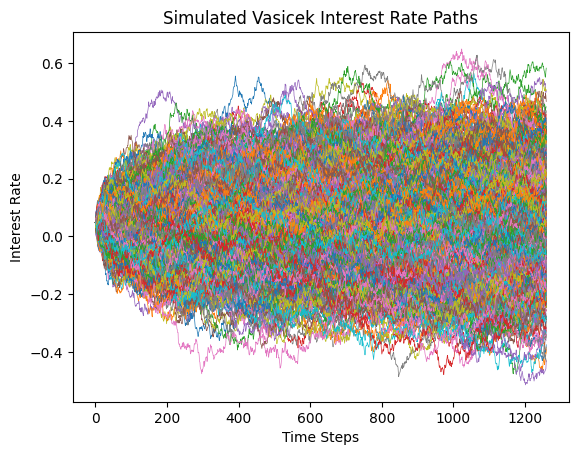

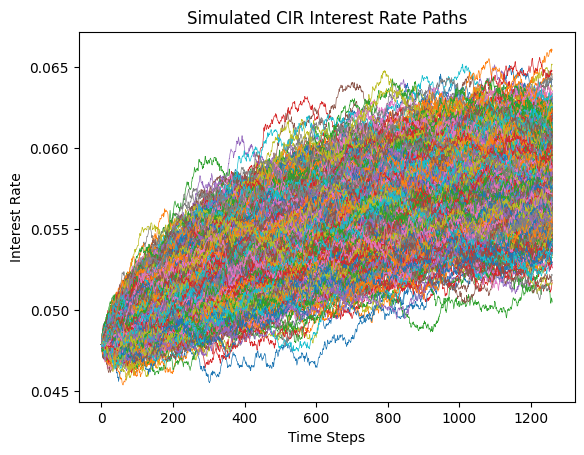

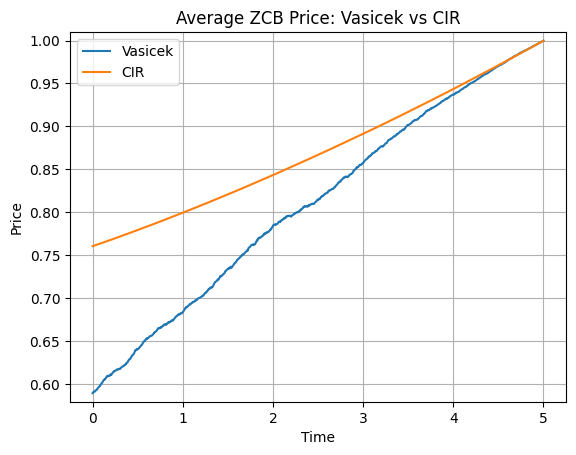

In [ ]:
# Plotting Vasicek
plt.plot(rates_v.T, lw=0.5)
plt.title("Simulated Vasicek Interest Rate Paths")
plt.xlabel("Time Steps")
plt.ylabel("Interest Rate")
plt.show()
# Plotting CIR
plt.plot(rates_CIR.T, lw=0.5)
plt.title("Simulated CIR Interest Rate Paths")
plt.xlabel("Time Steps")
plt.ylabel("Interest Rate")
plt.show()
# Plotting ZCB prices, Vasicek vs CIR
plt.plot(np.linspace(0, T, num_steps), prices.mean(axis=0), label="Vasicek")
plt.plot(np.linspace(0, T, num_steps), prices_CIR.mean(axis=0), label="CIR")
plt.title("Average ZCB Price: Vasicek vs CIR")
plt.xlabel("Time")
plt.ylabel("Price")
#just to have a better view of the plot:
#calculate min and max mean prices for both models
#and set the y-axis limits with a margin
min_price = min(prices.mean(axis=0).min(), prices_CIR.mean(axis=0).min())
max_price = max(prices.mean(axis=0).max(), prices_CIR.mean(axis=0).max())
margin = 0.01
plt.ylim([min_price - margin, max_price + margin])
plt.legend()
plt.grid()
plt.show()
